In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [4]:
df = pd.read_csv('creditcard.csv')
print(df.shape)

(284807, 31)


In [5]:
print(df.columns.tolist())

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [6]:
print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [7]:
print(df['Class'].value_counts())


Class
0    284315
1       492
Name: count, dtype: int64


In [8]:
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [9]:
print(df.describe())


                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.175161e-15  3.384974e-16 -1.379537e-15  2.094852e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   1.021879e-15  1.494498e-15 -5.620335e-16  1.149614e-16 -2.414189e-15   
std    1.380247e+00  1.332271e+00  1.23709

C:\Users\ELCOT\AppData\Local\Temp\ipykernel_14556\370639111.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette=['steelblue', 'crimson'])


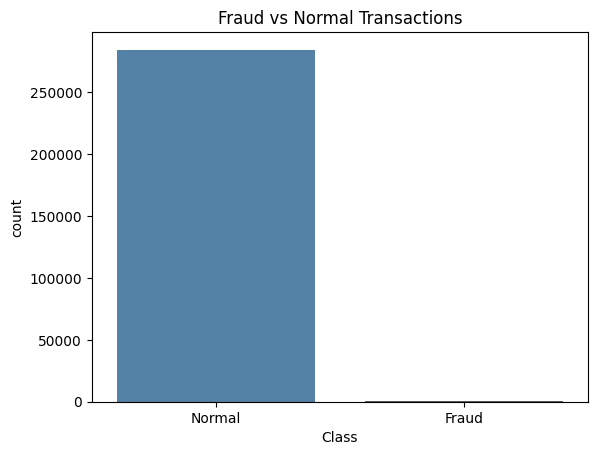

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Class', data=df, palette=['steelblue', 'crimson'])
plt.title('Fraud vs Normal Transactions')
plt.xticks([0, 1], ['Normal', 'Fraud'])
plt.show()

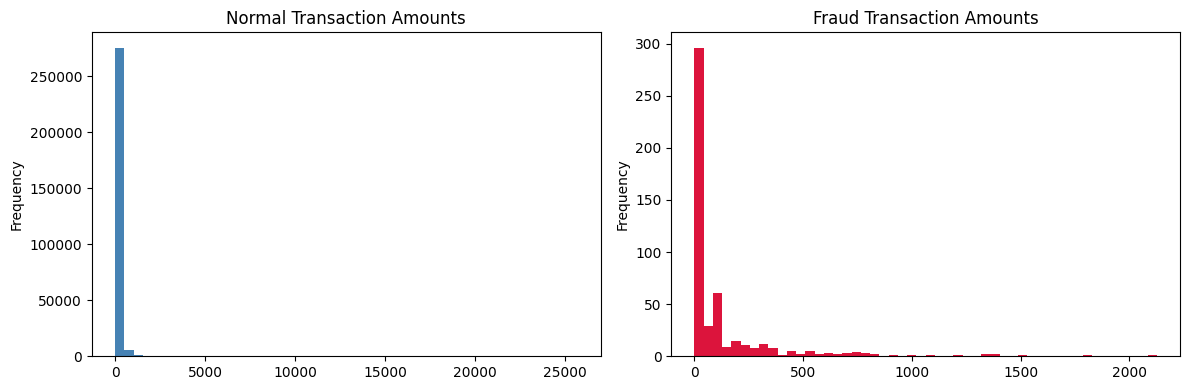

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df[df['Class']==0]['Amount'].plot(kind='hist', bins=50, ax=axes[0], 
                                   title='Normal Transaction Amounts', color='steelblue')

df[df['Class']==1]['Amount'].plot(kind='hist', bins=50, ax=axes[1], 
                                   title='Fraud Transaction Amounts', color='crimson')
plt.tight_layout()
plt.show()

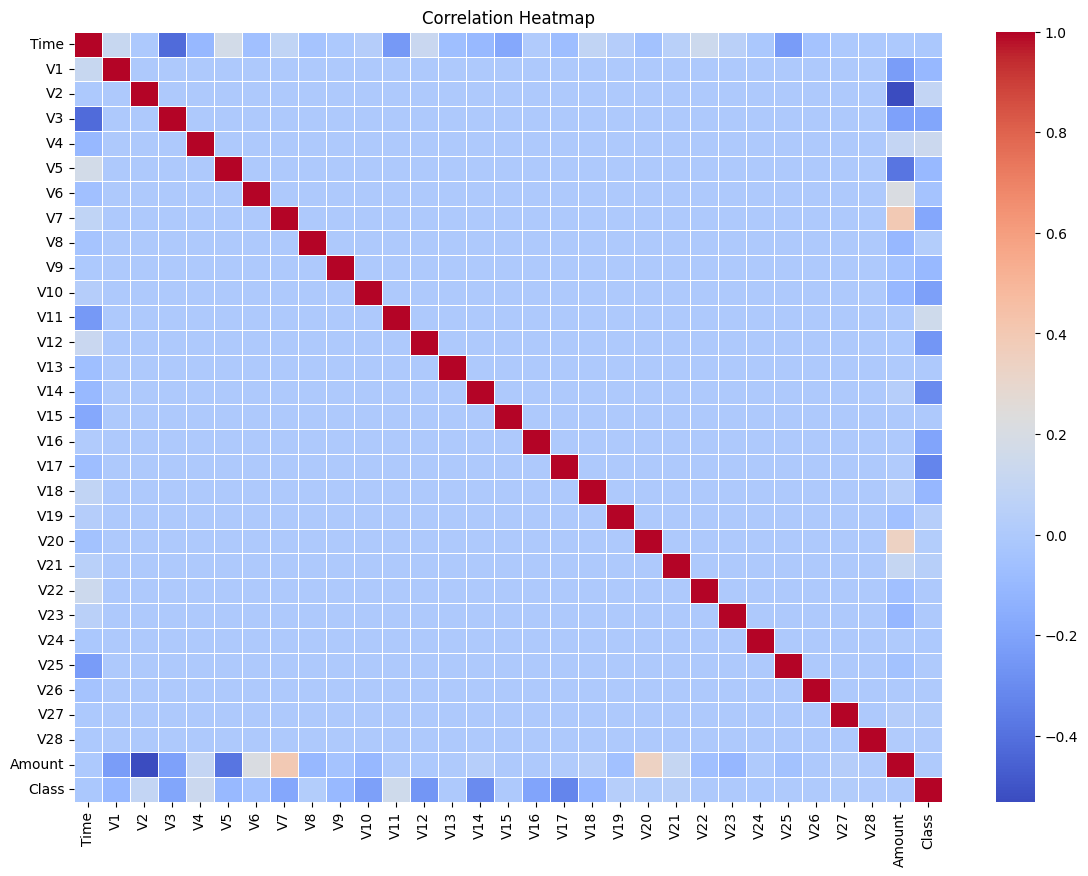

In [12]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df['scaled_amount'] = scaler.fit_transform(df[['Amount']])
df['scaled_time']   = scaler.fit_transform(df[['Time']])

df.drop(['Amount', 'Time'], axis=1, inplace=True)

print("Scaling done!")
print(df.shape)

Scaling done!
(284807, 31)


In [14]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (227845, 30)
X_test shape: (56962, 30)
y_train shape: (227845,)
y_test shape: (56962,)


In [15]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE:  {y_train_res.value_counts().to_dict()}")

Before SMOTE: {0: 227451, 1: 394}
After SMOTE:  {0: 227451, 1: 227451}


In [16]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_res, y_train_res)

print("Logistic Regression training done!")

Logistic Regression training done!


In [29]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_res, y_train_res)

print("Random Forest training done!")

Random Forest training done!


In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_res, y_train_res)

print("XGBoost training done!")

XGBoost training done!


In [ ]:
from sklearn.metrics import classification_report

y_pred_lr  = lr_model.predict(X_test)
y_pred_rf  = rf_model.predict(X_test)
y_pred_xgb = xgb_model.predict(X_test)

print("===== Logistic Regression =====")
print(classification_report(y_test, y_pred_lr))

print("===== Random Forest =====")
print(classification_report(y_test, y_pred_rf))

print("===== XGBoost =====")
print(classification_report(y_test, y_pred_xgb))

===== Logistic Regression =====
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

===== Random Forest =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.82      0.82        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962

===== XGBoost =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.73      0.89      0.80        98

    accuracy                           1.00     56962
   macro avg       0.87      0.94      0.90     56

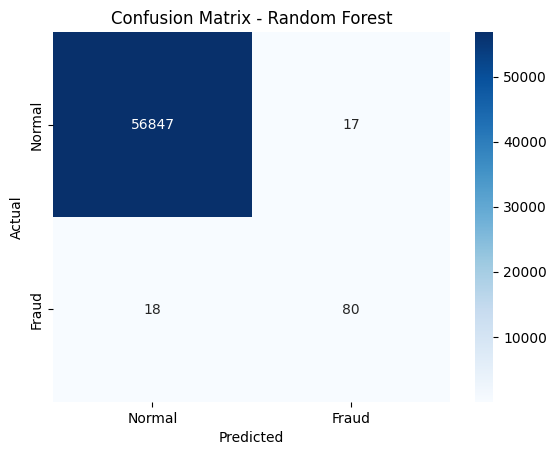

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [18]:
import joblib

joblib.dump(rf_model, 'fraud_detection_model.pkl')
print("Model saved successfully!")

Model saved successfully!


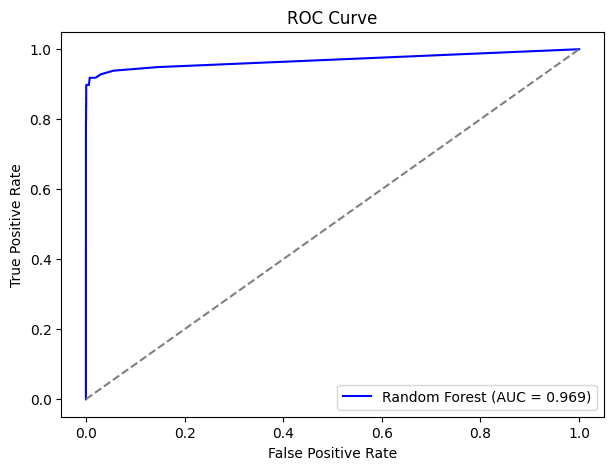

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score

rf_model2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model2.fit(X_train_res, y_train_res)

y_prob_rf = rf_model2.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
auc = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc:.3f})', color='blue')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve') 
plt.legend()
plt.show()

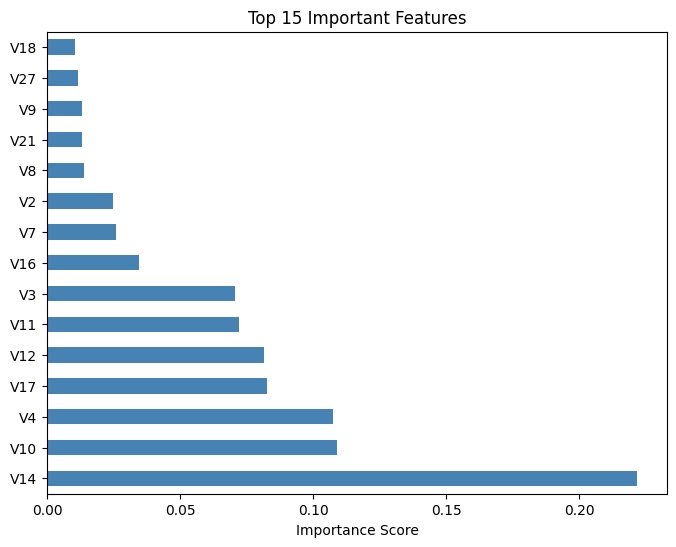

In [26]:
feat_imp = pd.Series(rf_model2.feature_importances_, index=X.columns)
feat_imp.nlargest(15).plot(kind='barh', figsize=(8, 6), color='steelblue')
plt.title('Top 15 Important Features')
plt.xlabel('Importance Score')
plt.show()

In [ ]:
# Test with one normal transaction
sample = X_test.iloc[0].values.reshape(1, -1)
actual = y_test.iloc[0]

prediction = rf_model2.predict(sample)

print(f"Actual Class:     {'FRAUD' if actual == 1 else 'NORMAL'}")
print(f"Predicted Class:  {'FRAUD' if prediction[0] == 1 else 'NORMAL'}")

if actual == prediction[0]:
    print("✅ Model predicted CORRECTLY!")
else:
    print(" Model predicted WRONGLY!")

Actual Class:     NORMAL
Predicted Class:  NORMAL
✅ Model predicted CORRECTLY!


c:\Users\ELCOT\Desktop\credit card fraud detection\fraud_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# Find a fraud transaction from test data
fraud_indices = y_test[y_test == 1].index
fraud_sample = X_test.loc[fraud_indices[0]].values.reshape(1, -1)
actual_fraud = y_test.loc[fraud_indices[0]]

prediction_fraud = rf_model2.predict(fraud_sample)

print(f"Actual Class:     {'FRAUD' if actual_fraud == 1 else 'NORMAL'}")
print(f"Predicted Class:  {'FRAUD' if prediction_fraud[0] == 1 else 'NORMAL'}")

if actual_fraud == prediction_fraud[0]:
    print("✅ Model predicted CORRECTLY!")
else:
    print(" Model predicted WRONGLY!")

Actual Class:     FRAUD
Predicted Class:  FRAUD
✅ Model predicted CORRECTLY!


c:\Users\ELCOT\Desktop\credit card fraud detection\fraud_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
